# 연수입과 지출점수로 고객을 나누면 어떤 고객군이 보이는가

**작성자:** bolly0809-coder &nbsp;&nbsp;|&nbsp;&nbsp; **작성일:** 2026-09-03

[프로젝트 요약 · 핵심 결과 · 참고자료 · 회고](README.md)

## Mall Customers 고객 세분화

고객의 연수입과 지출점수로 K-means 군집을 구성하고, 나이·성별을 함께 살펴 각 고객군의 특성과 활용 방안을 정리했다.

### 핵심 결과

- 고객 200명을 5개 군집으로 구분했다. 중간 소득·중간 지출점수 군집이 81명(40.5%)으로 가장 컸다.
- 엘보우 포인트와 비교한 후보 중 가장 높은 실루엣 점수(약 0.555)가 모두 `k=5`를 지지했다. 균형지수의 자동 추천 `k=2`와는 구분하여 판단했다.
- 높은 소득·낮은 지출점수 고객 35명(17.5%)과 높은 소득·높은 지출점수 고객 39명(19.5%)을 구분할 수 있었다. 소득만으로 지출점수를 설명하기는 어렵다.
- 새로운 고객 사례 3명을 기존 군집에 배정했다. 활용 방안은 제안이며 캠페인의 효과를 검증한 결과는 아니다.

### 분석 범위 및 실행 안내

- 진행 순서: 데이터 준비 → 표준화 → 군집 수 검토 및 K-means → 군집별 진단·k=2 비교 → 페르소나 해석 → 새 고객 배정 → 활용 검증 계획
- 군집화 변수: 연수입, 지출점수 / 추가 해석 변수: 나이, 성별
- 20개 코드 셀의 저장된 실행 결과, 그래프 7개, 군집별 진단과 해석을 포함한다. 모델링 코드와 출력은 보존했다.
- 공개 파일은 README와 이 노트북이다. `helpers`·데이터·모델 파일은 포함하지 않으며, 표와 그래프는 노트북 안에서 열람할 수 있다.
- 재실행에는 Python 3.13, 별도로 보유한 `helpers`, `jussam`과 관련 분석 패키지가 필요하다. 첫 경로 설정 셀을 본인 환경에 맞춰야 한다.
- 로컬 실행 중 `models/mall_scaler.pkl`이 저장되며, 학습된 K-means 모델을 별도 저장하는 코드는 없다.


In [35]:
# 로컬 실행 경로만 지정한다. 분석 방법이나 파라미터를 변경하지 않는다.
from pathlib import Path
import os
import sys

project_dir = Path('C:\\Users\\jh\\취준_데이터분석_0901\\kaggle프로젝트\\Mall Customers 고객 세분화')
os.chdir(project_dir)
sys.path.insert(0, str(project_dir))
print("작업 폴더:", project_dir)


작업 폴더: C:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Mall Customers 고객 세분화


## #01. 준비작업

### 1. 라이브러리 참조

In [36]:
from jussam import load_data
from helpers import *

from pandas import DataFrame, crosstab
import joblib

# 정규성 검정
from scipy.stats import normaltest

### 2. 데이터 가져오기

`jussam.load_data("mall_customers")`로 불러온 고객 데이터이다. 저장된 데이터 정보 출력에서 **200행·5개 변수이며 각 변수에 결측값이 없음**을 확인했다. 고객ID는 식별자이므로 군집화 변수에서 제외했다.

데이터 로더에 표시된 출처: [Mall Customers 데이터셋](https://www.kaggle.com/datasets/shwetabh123/mall-customers).


In [37]:
origin = load_data("mall_customers")
origin.head()

📚 이 데이터 세트는 쇼핑몰 고객의 인구통계학적 특성과 소비 습관에 대한 정보를 담고 있습니다. 고객 ID, 성별, 나이, 연간 소득, 지출 점수와 같은 다양한 속성이 포함되어 있습니다. (출처: https://www.kaggle.com/datasets/shwetabh123/mall-customers)


,고객ID,성별,나이,연수입,지출점수
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 3. 데이터 전처리 - 변수 타입 정리

`성별` 은 문자열이지만 의미상 **범주형**이다. 타입을 지정해 두면 뒤에서 연속형/범주형을 자동으로 구분할 수 있다.

In [38]:
origin = my_qtcheck.set_type(origin, as_category=["성별"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   고객ID    200 non-null    int64   
 1   성별      200 non-null    category
 2   나이      200 non-null    int64   
 3   연수입     200 non-null    int64   
 4   지출점수    200 non-null    int64   
dtypes: category(1), int64(4)
memory usage: 6.7 KB


### 4. 군집화에 사용할 변수 선택

In [39]:
df = origin[["연수입", "지출점수"]]
df.head()

,연수입,지출점수
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


### 5. 데이터 스케일링

연수입과 지출점수의 척도를 맞추기 위해 표준화한다. 새 고객 사례에도 같은 기준을 적용하도록 스케일러를 저장한다.

이후 `best_k(df)`와 `kmeans(df)`는 원본 `df`를 받아 내부에서 같은 표준화를 수행한다. 아래 `sdf`를 다시 표준화하는 것이 아니므로 변환이 중복 누적되지 않는다. 저장된 스케일러 역시 같은 두 변수와 같은 200행으로 학습된다.


In [40]:
# save_path 를 지정하면 학습된 스케일러가 파일로 저장된다
# --> 신규 고객을 '똑같은 기준'으로 변환할 때 다시 불러 쓴다
sdf = my_prep.scaling(df, method="standard", 
                      save_path="models/mall_scaler.pkl")
sdf.head()

StandardScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
연수입               15.00 ~ 137.00          -1.74 ~ 2.92
지출점수                1.00 ~ 99.00          -1.91 ~ 1.89

스케일러 저장: models/mall_scaler.pkl (StandardScaler)


,연수입,지출점수
0,-1.739,-0.435
1,-1.739,1.196
2,-1.701,-1.716
3,-1.701,1.040
4,-1.663,-0.396


## #02. 군집 모형 적합

### 1. 군집 수 검토


StandardScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
연수입               15.00 ~ 137.00          -1.74 ~ 2.92
지출점수                1.00 ~ 99.00          -1.91 ~ 1.89


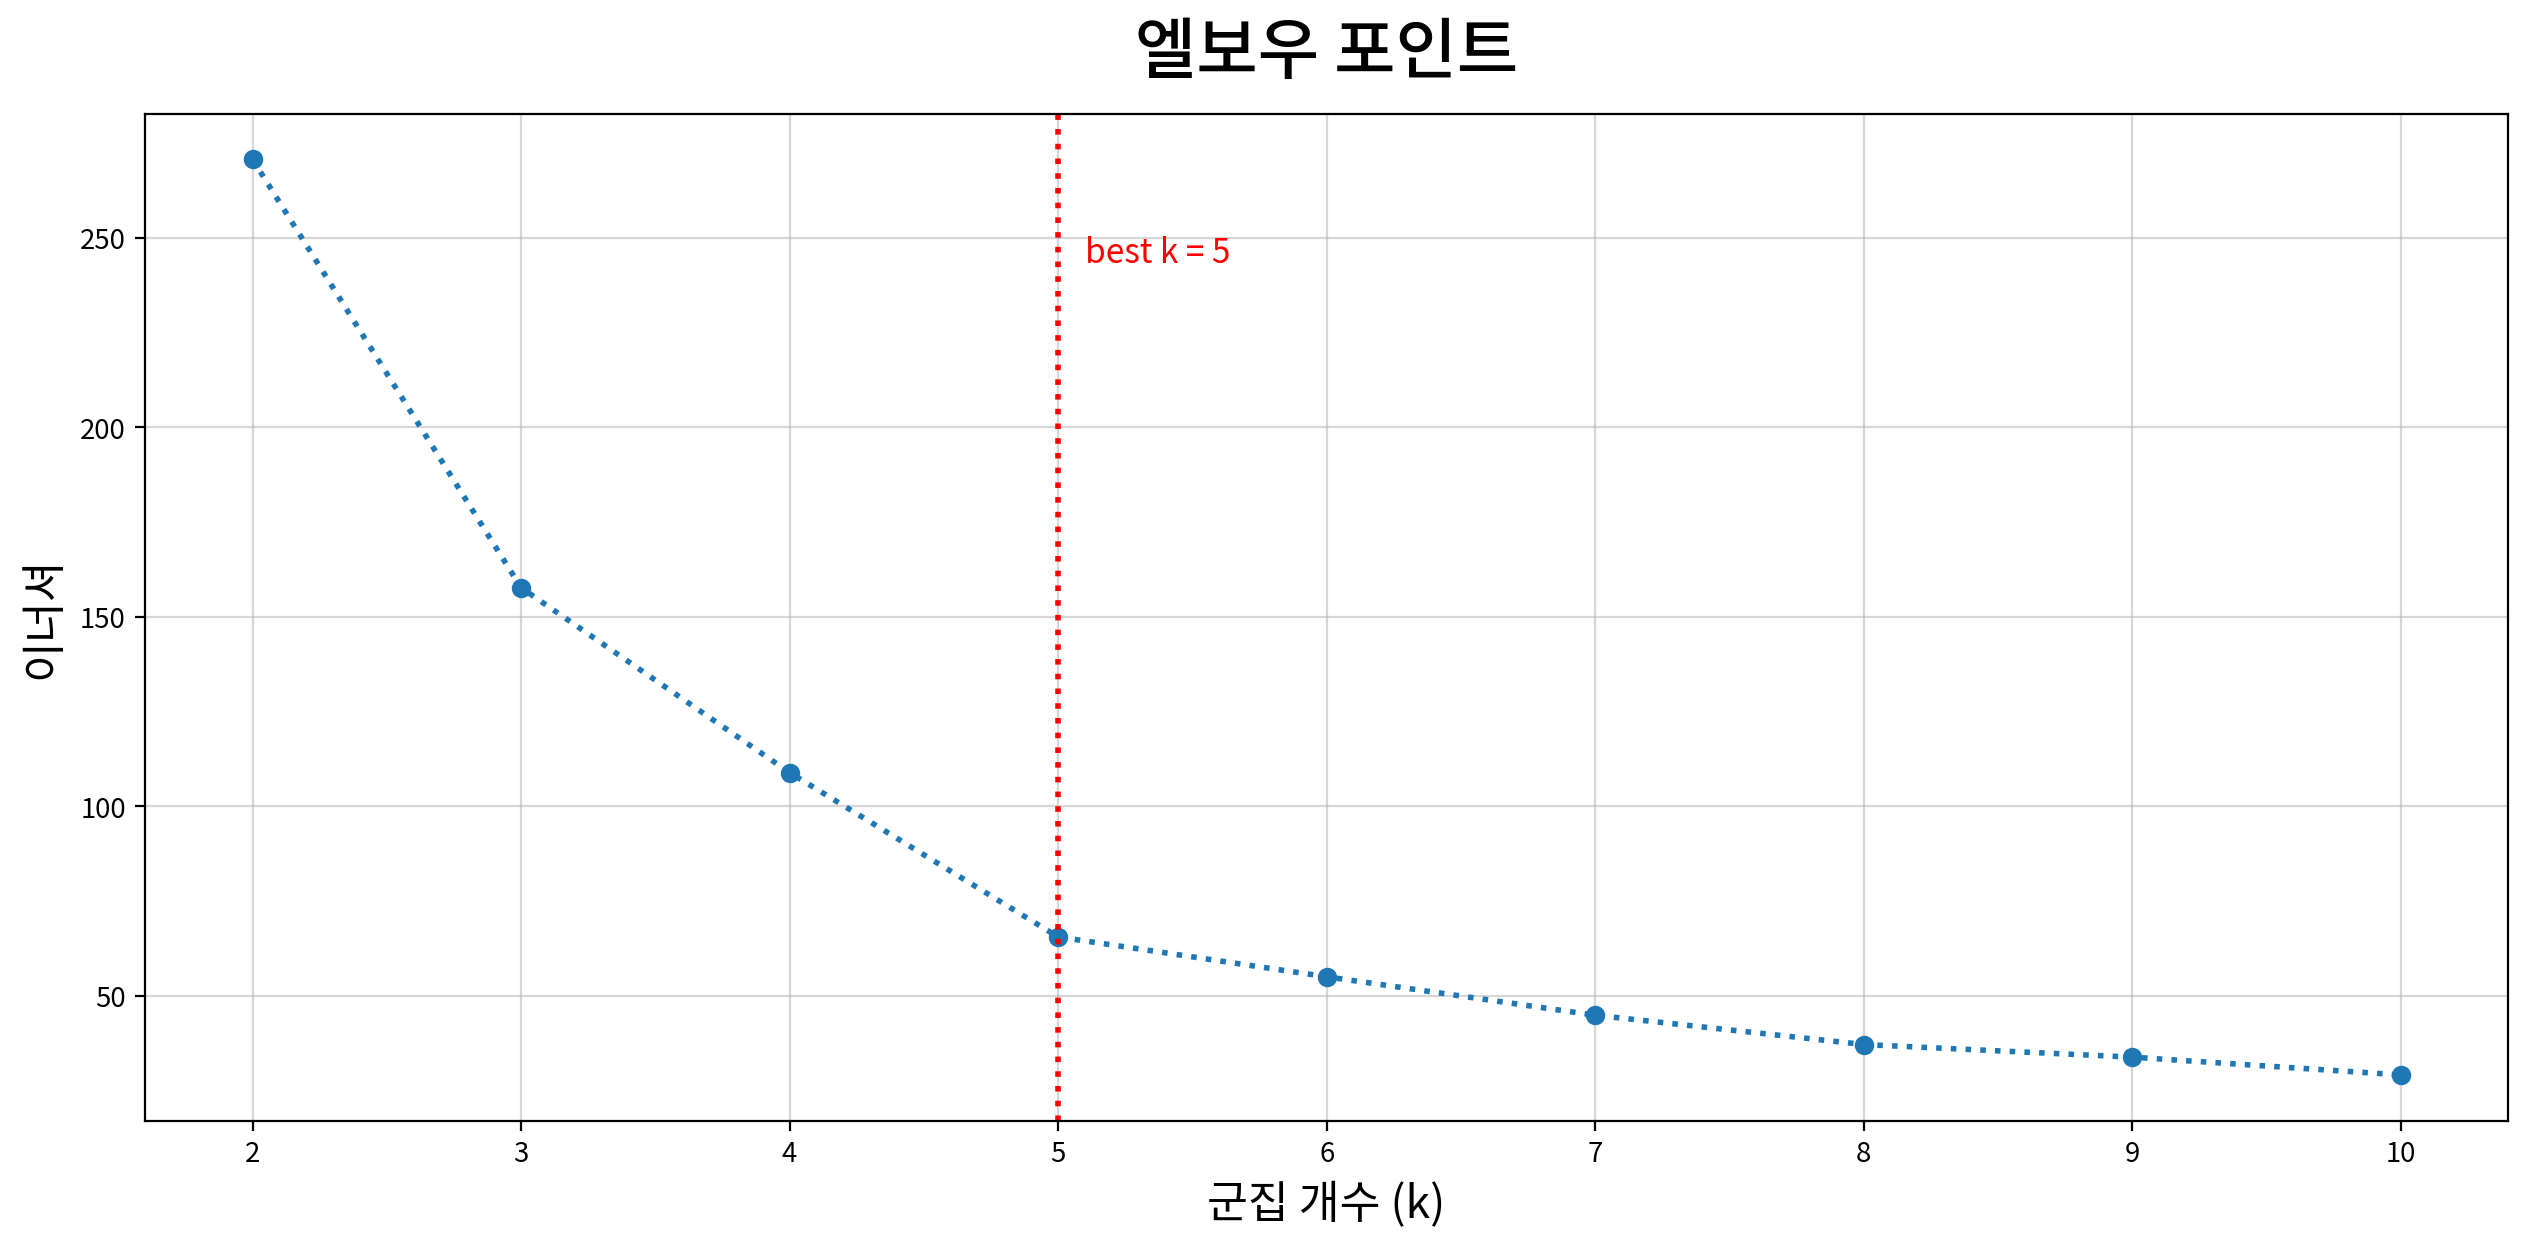

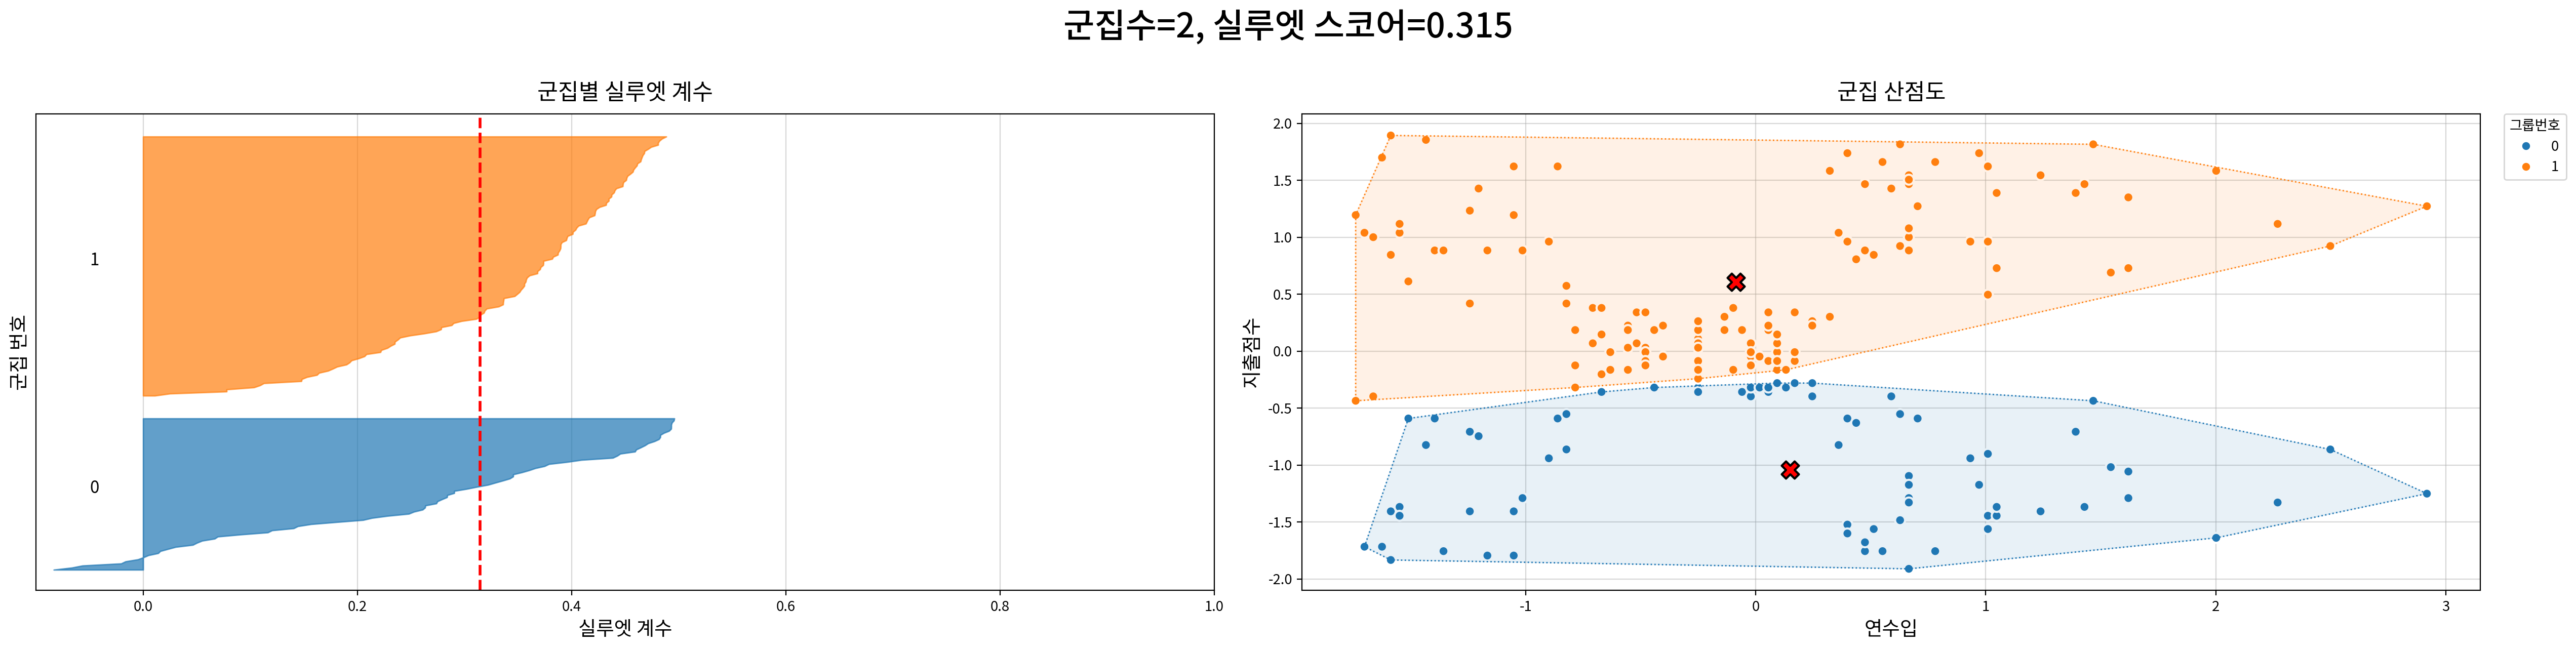

[1단계] 엘보운 포인트       : k = 5  (뭉침만 확인 -> 후보)
[2단계] 실루엣 균형지수     : k = 2  (뭉침 + 분리 + 크기 균형)
두 지표가 다른 k를 가리킵니다.
    · k = 5 : 균형지수 0.0797 (스코어 0.5547, 두께비 3.6818)
------------------------------------------------------------
>>> 최종 선택:k = 2
 (지표는 후보를 좁혀줄 뿐이므로, 목적과 도메인 지식으로 한 번 더 확인할 것)


,k,이너셔,감소량,스코어,전체면적,두께비,최소상대면적,균형지수
0,2,270.704,NaN,0.315,62.940,1.703,0.628,0.116
1,3,157.704,113.000,0.467,93.317,3.237,0.685,0.099
2,4,108.921,48.783,0.494,98.781,4.348,0.516,0.059
3,5,65.568,43.353,0.555,110.931,3.682,0.529,0.080
4,6,55.057,10.511,0.540,107.976,8.100,0.182,0.012
5,7,44.911,10.146,0.526,105.269,7.900,0.227,0.015
6,8,37.182,7.729,0.456,91.240,4.300,0.287,0.030
7,9,33.854,3.328,0.455,91.058,6.125,0.301,0.022
8,10,29.167,4.687,0.448,89.634,6.571,0.262,0.018


In [41]:
final_k, result_df = my_cluster.best_k(df, verbose=True)
result_df

### 군집 수 평가 결과

`helpers`의 균형지수는 다음과 같이 계산되는 복합 지표이다.

**균형지수 = 실루엣 점수 × 최소상대면적 ÷ 두께비**

- 실루엣 점수: 개별 관측값의 실루엣 계수 평균
- 두께비: 가장 큰 군집의 인원 ÷ 가장 작은 군집의 인원
- 최소상대면적: 군집별 실루엣 계수 합 중 최솟값 ÷ 전체 실루엣 계수 합 × 군집 수(전체 합이 양수일 때)

| 비교 항목 | k=2 | k=5 |
|---|---:|---:|
| 실루엣 점수 | 약 0.315 | 약 0.555 |
| 두께비 | 약 1.703 | 약 3.682 |
| 최소상대면적 | 약 0.628 | 약 0.529 |
| 균형지수 | 약 0.116 | 약 0.080 |

균형지수 기준의 자동 추천은 **`final_k=2`**이다. `k=5`는 일반 실루엣 점수가 더 높지만 군집 크기와 면적의 불균형이 반영되어 균형지수가 낮아졌다. 바로 위 실루엣 그림은 이 자동 추천 후보인 **k=2**의 결과이며, 최종 분석에 사용한 k=5의 그림과 구분해야 한다.


### 2. 분석에 사용할 k 결정

최종 분석은 **`best_k=5`**로 진행한다.

1. 엘보우 포인트가 `k=5`로 탐지됐다. 이너셔 감소량은 k=4→5에서 약 43.353, k=5→6에서 약 10.511로 줄었다.
2. 비교한 k=2~10 중 일반 실루엣 점수가 k=5에서 약 0.555로 가장 높았다.
3. 소득과 지출점수의 조합에 따라 고객군을 세분화하는 목적에 맞게 해석할 수 있었다.

이는 자동 추천을 그대로 사용한 것이 아니라 **군집 간 분리, 엘보우 포인트, 해석 목적을 종합한 선택**이다. 군집 크기 균형을 우선하면 k=2가 더 유리하다는 점을 함께 남긴다. 모든 목적에서 k=5가 유일한 정답이라는 뜻은 아니다.

구매 빈도를 측정한 자료가 아니므로 5개 군집을 신규·반복·고빈도 구매 고객으로 해석하지 않는다.


In [42]:
best_k = 5

### 3. 모형 적합

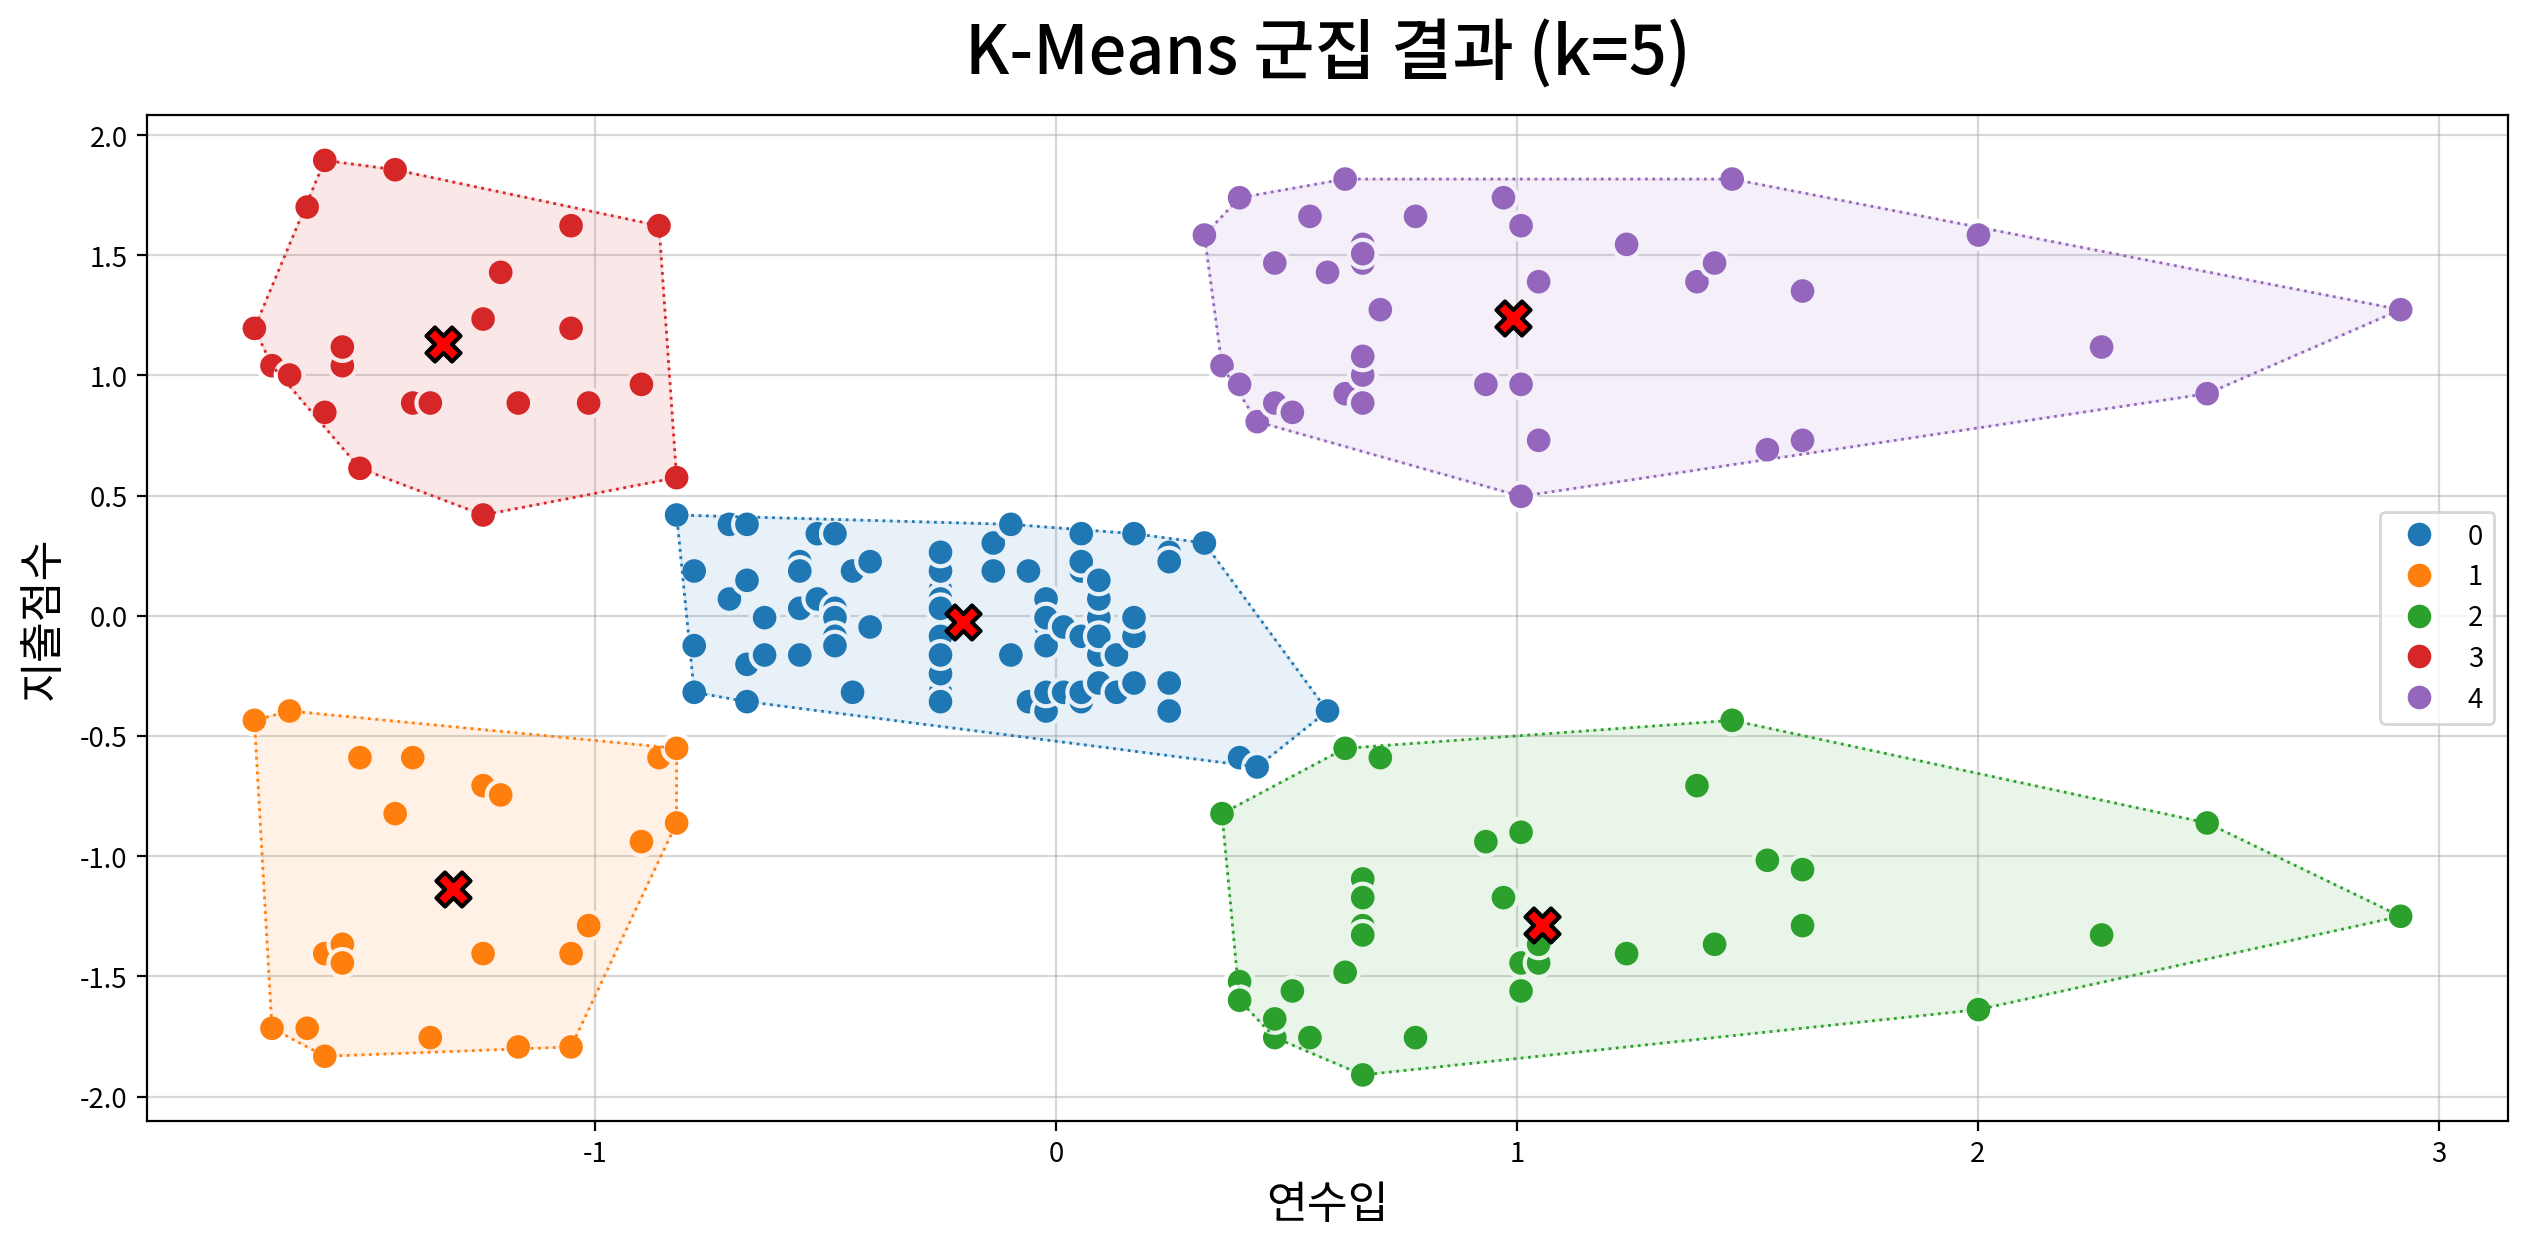

In [43]:
# my_cluster.kmeans() 가 학습 → 군집 번호 부여 → 중심점 정리까지 한 번에 처리한다
estimator, cdf, center_df = my_cluster.kmeans(df, k=best_k, 
                            cluster_name="ClusterID", verbose=False)

### 4. 군집 형태 확인

바로 앞 모형 적합에서 출력된 그래프의 축과 중심점은 **표준화 값**이다. 아래에서는 동일한 군집 번호를 원본 `df`에 붙여 **원본 단위**로 산점도를 그린다. 따라서 군집 배정은 같고, 축의 척도만 달라진다.


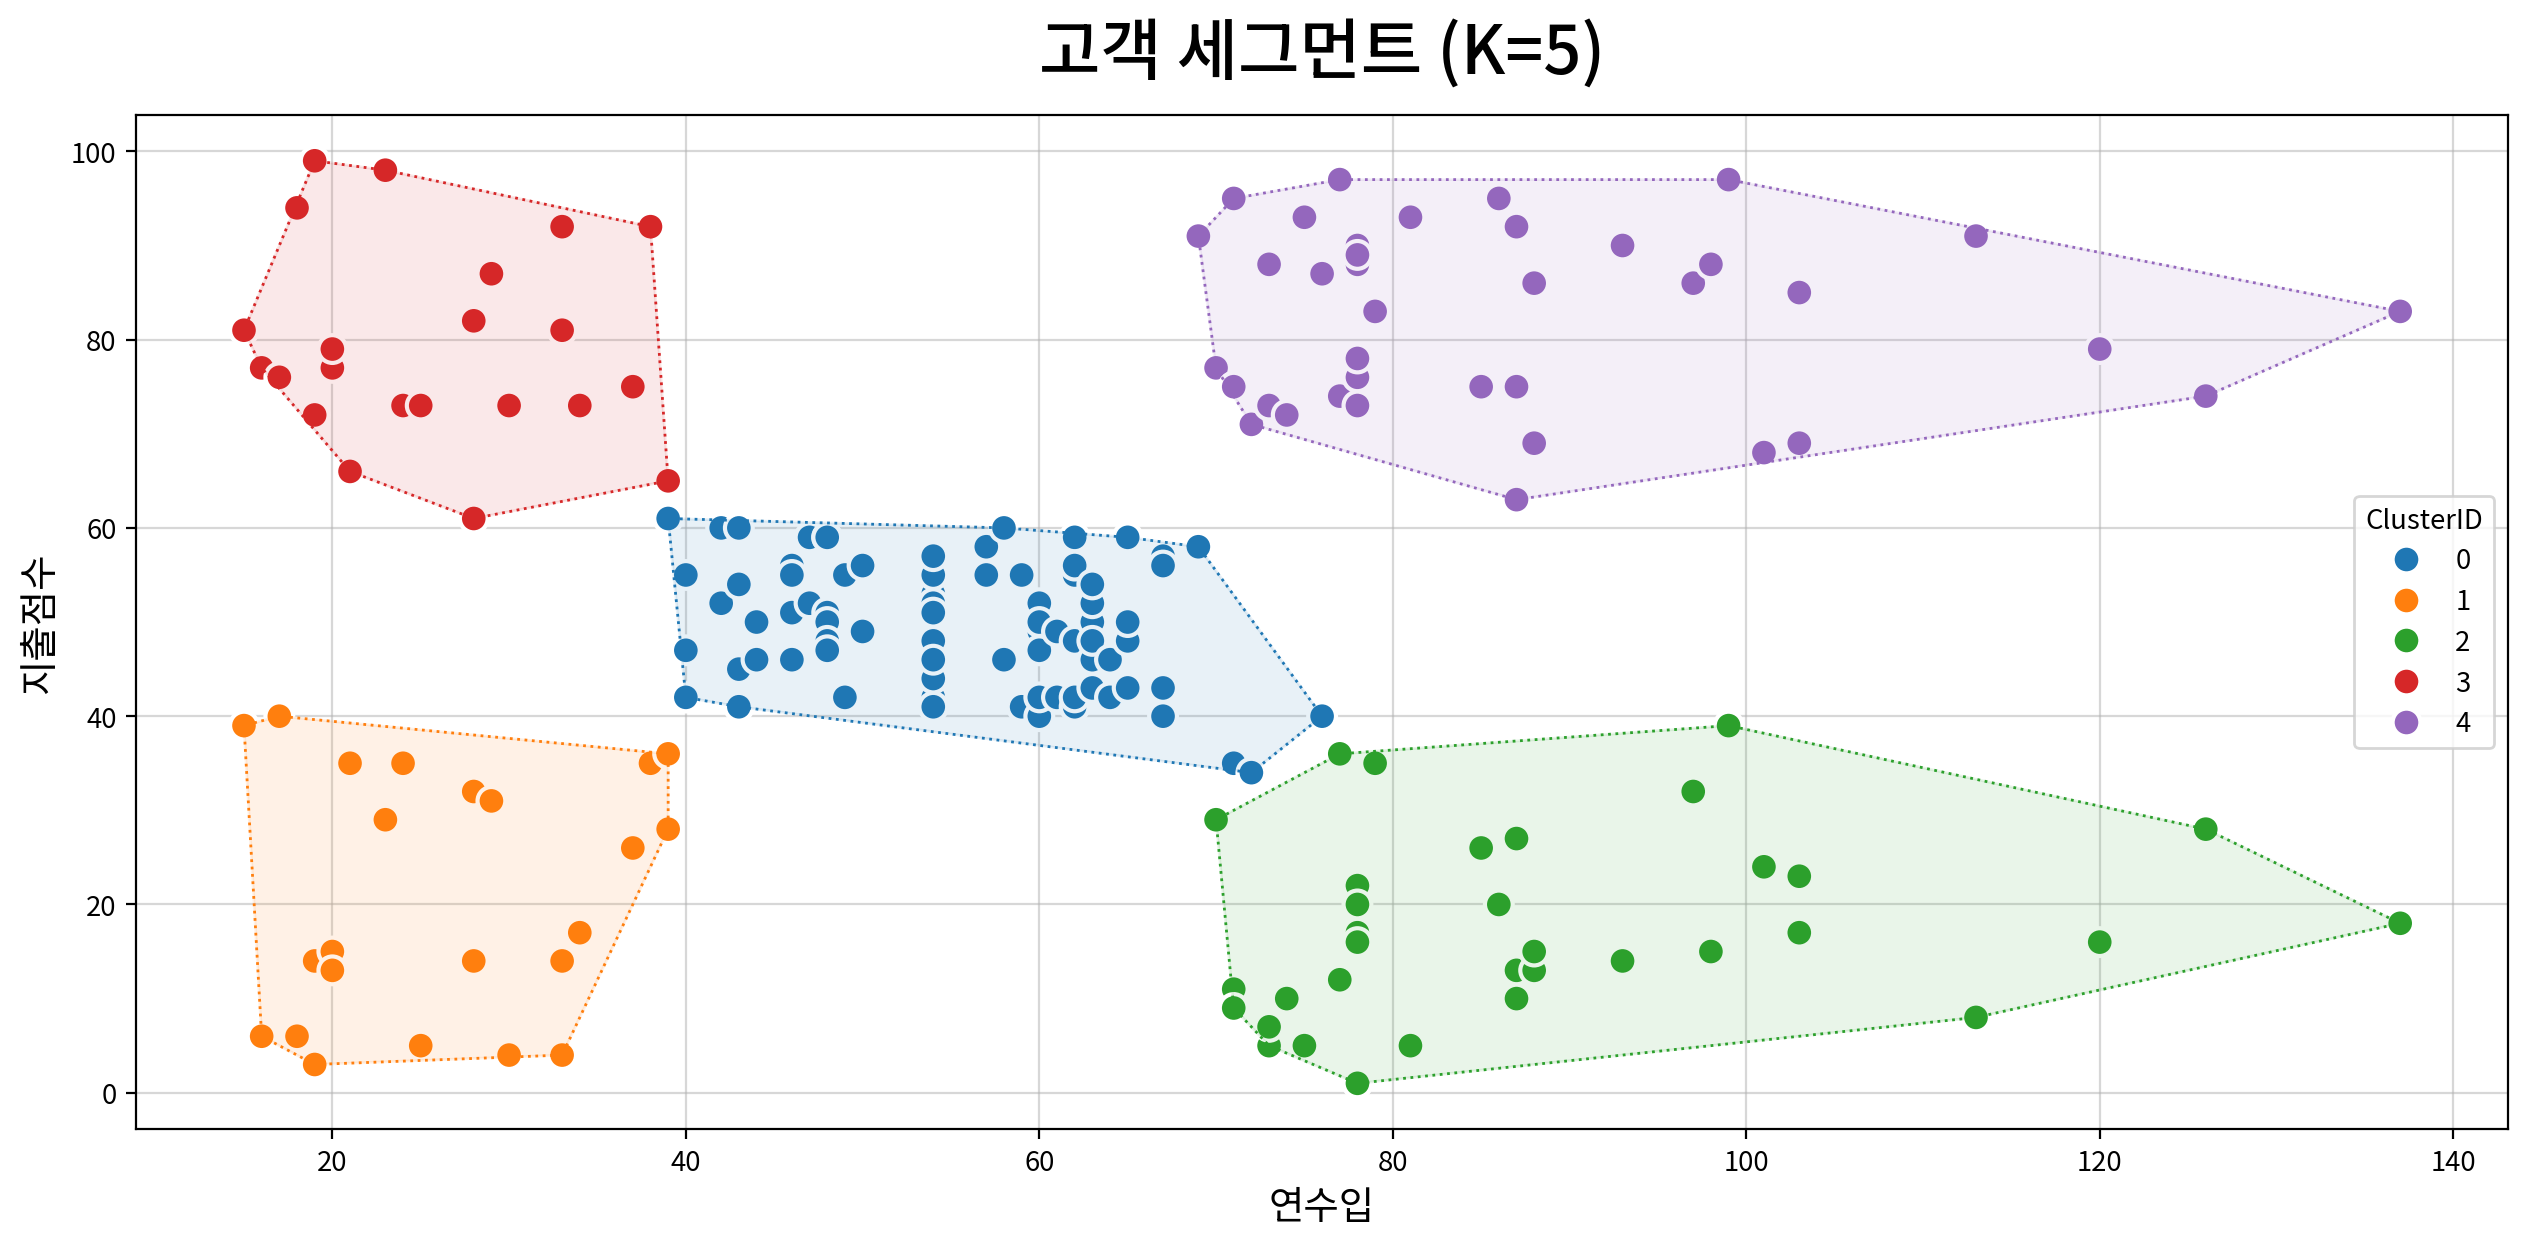

In [44]:
vdf = df.copy()                         # 원본 데이터 복사
vdf["ClusterID"] = estimator.labels_    # 복사한 원본에 군집 번호 컬럼 추가

my_plot.scatterplot(data=vdf, x="연수입", y="지출점수", hue="ClusterID", 
                    title=f"고객 세그먼트 (K={best_k})", palette="tab10")

#### 고객군 해석

산점도와 아래 페르소나 집계를 함께 확인하면 다음 5개 고객군으로 정리된다.

| 군집 | 연수입·지출점수 기준 특성 | 인원 | 비중 |
|---|---|---:|---:|
| 0 | 중간 소득·중간 지출점수 | 81명 | 40.5% |
| 1 | 낮은 소득·낮은 지출점수 | 23명 | 11.5% |
| 2 | 높은 소득·낮은 지출점수 | 35명 | 17.5% |
| 3 | 낮은 소득·높은 지출점수 | 22명 | 11.0% |
| 4 | 높은 소득·높은 지출점수 | 39명 | 19.5% |

높고 낮음은 **이 표본 안에서의 상대적인 구분**이다. 지출점수는 실제 지출액 자체가 아니며, 군집 번호에도 순위의 의미는 없다.

소득이 높은 고객이 모두 높은 지출점수를 갖지는 않는다. 군집 2와 4를 구분하여 고객 접근 방안을 검토할 수 있다. 다만 산점도의 형태만으로 두 변수의 통계적 독립성이나 인과관계를 입증한 것은 아니다.


### 5. 최종 5개 군집의 분리 상태 진단

전체 평균 실루엣 점수만으로는 개별 군집의 상태를 알기 어렵다. 최종 모델의 군집별 실루엣 분포, 평균, 음수인 고객 수를 확인한다. 새 모델을 만들지 않고 앞서 학습한 `estimator`와 같은 표준화 데이터 `sdf`를 사용한다.

- 계수가 1에 가까울수록 다른 군집과 잘 분리되어 있다. 0 부근은 군집 경계에 가까운 경우이며, 음수이면 다른 군집과의 평균 거리가 현재 군집 내 평균 거리보다 작다.
- 정답 라벨이 없으므로 음수라고 해서 실제 고객이 '오분류됐다'고 확정하지 않는다.
- 경계 사례를 살펴보기 위해 **실루엣 계수 0.1 이하**를 검토 대상으로 정한다. 이는 이 보고서의 탐색용 기준이지 보편적인 합격·불합격 기준이 아니다. 이 기준으로 고객을 삭제하거나 군집을 다시 배정하지 않는다.
- 그림의 빨간 선은 전체 평균이다. 그보다 낮다고 군집이 자동으로 잘못된 것은 아니다. 같은 군집의 분포와 음수 사례를 함께 읽는다.

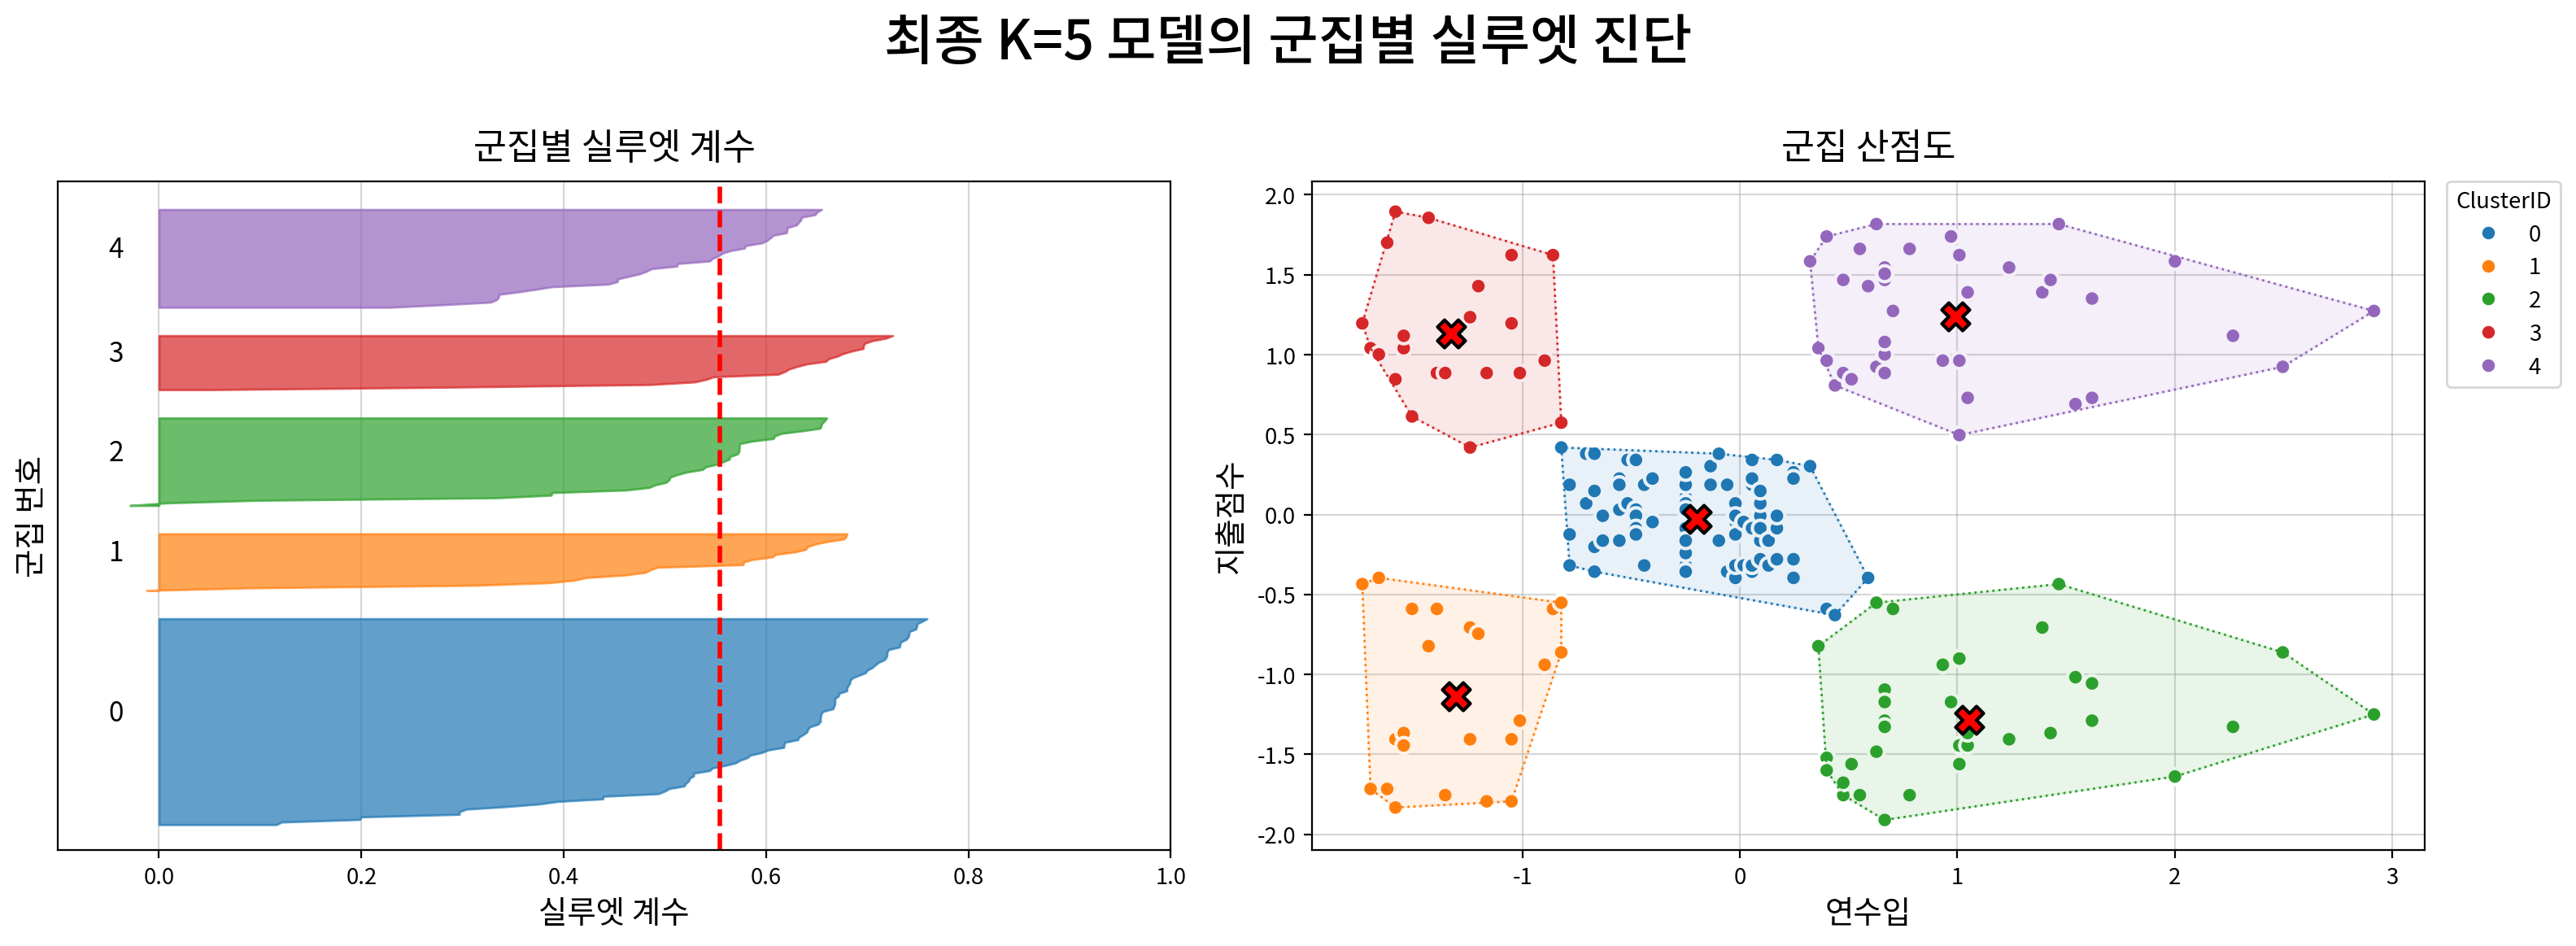

In [45]:
# helpers 내부에서도 사용하는 실루엣 계수 계산 함수를 그대로 활용한다.
from sklearn.metrics import silhouette_samples
from IPython.display import display, Markdown

my_cluster.visualize_silhouette(
    estimator, sdf, columns=list(df.columns), cluster_name="ClusterID",
    title="최종 K=5 모델의 군집별 실루엣 진단", palette="tab10"
)

quality_df = origin[["고객ID", "연수입", "지출점수"]].copy()
quality_df["ClusterID"] = estimator.labels_
quality_df["실루엣"] = silhouette_samples(sdf, estimator.labels_)
quality_df["음수여부"] = quality_df["실루엣"] < 0
quality_df["경계검토여부"] = quality_df["실루엣"] <= 0.1

In [46]:
cluster_quality = quality_df.groupby("ClusterID").agg(
    인원=("실루엣", "size"),
    평균실루엣=("실루엣", "mean"),
    최소실루엣=("실루엣", "min"),
    음수고객수=("음수여부", "sum"),
    경계검토고객수=("경계검토여부", "sum")
)
cluster_quality["경계검토비율(%)"] = (
    cluster_quality["경계검토고객수"] / cluster_quality["인원"] * 100
)
display(cluster_quality.round(3))

# 경계 검토에는 음수 사례도 포함된다. 두 인원수를 더하면 중복 집계가 된다.
boundary_customers = quality_df.loc[
    quality_df["경계검토여부"], ["고객ID", "연수입", "지출점수", "ClusterID", "실루엣"]
].sort_values("실루엣")
display(Markdown("#### 경계 검토 고객 — 실루엣이 낮은 순서, 최대 10명"))
display(boundary_customers.head(10).round(3))

weak_cluster = cluster_quality["평균실루엣"].idxmin()
negative_count = int(quality_df["음수여부"].sum())
boundary_count = int(quality_df["경계검토여부"].sum())
display(Markdown(
    f"**실행 결과 해석:** 전체 평균 실루엣은 **{quality_df['실루엣'].mean():.3f}**이다. "
    f"평균이 가장 낮은 군집은 **{weak_cluster}**이며 "
    f"평균 계수는 **{cluster_quality.loc[weak_cluster, '평균실루엣']:.3f}**이다. "
    f"음수 사례는 **{negative_count}명**, 0.1 이하 경계 검토 사례는 "
    f"**{boundary_count}명({boundary_count / len(quality_df) * 100:.1f}%)**이다. "
    "이 결과는 동일한 표본 안에서의 분리 상태를 설명하며, "
    "다른 고객 집단에서의 성능이나 군집의 안정성을 검증한 것은 아니다."
))

,인원,평균실루엣,최소실루엣,음수고객수,경계검토고객수,경계검토비율(%)
ClusterID,,,,,,
0,81,0.598,0.116,0,0,0.000
1,23,0.511,-0.012,1,2,8.696
2,35,0.505,-0.029,1,3,8.571
3,22,0.598,0.050,0,1,4.545
4,39,0.511,0.228,0,0,0.000


#### 경계 검토 고객 — 실루엣이 낮은 순서, 최대 10명

,고객ID,연수입,지출점수,ClusterID,실루엣
146,147,77,36,2,-0.029
42,43,39,36,1,-0.012
124,125,70,29,2,0.008
45,46,39,65,3,0.050
40,41,38,35,1,0.091
160,161,79,35,2,0.097


**실행 결과 해석:** 전체 평균 실루엣은 **0.555**이다. 평균이 가장 낮은 군집은 **2**이며 평균 계수는 **0.505**이다. 음수 사례는 **2명**, 0.1 이하 경계 검토 사례는 **6명(3.0%)**이다. 이 결과는 동일한 표본 안에서의 분리 상태를 설명하며, 다른 고객 집단에서의 성능이나 군집의 안정성을 검증한 것은 아니다.

### 6. k=2와 k=5는 고객을 어떻게 다르게 구분하는가?

같은 두 변수, 표준화 방식, 난수 시드와 초기화 횟수로 k=2 모델을 한 번 학습한다. 비교 모델은 `estimator_k2`로 보관하여 최종 `estimator`와 `best_k=5`를 바꾸지 않는다.

교차표는 같은 고객이 두 모델에서 어느 군집에 배정되는지를 보여준다. 행 기준 비율은 각 k=2 군집의 고객이 k=5에서는 어떻게 나뉘는지 나타낸다. **서로 다른 모델의 군집 번호는 직접 대응하지 않으며, 두 결과가 계층적으로 포함된다고 가정하지 않는다.**

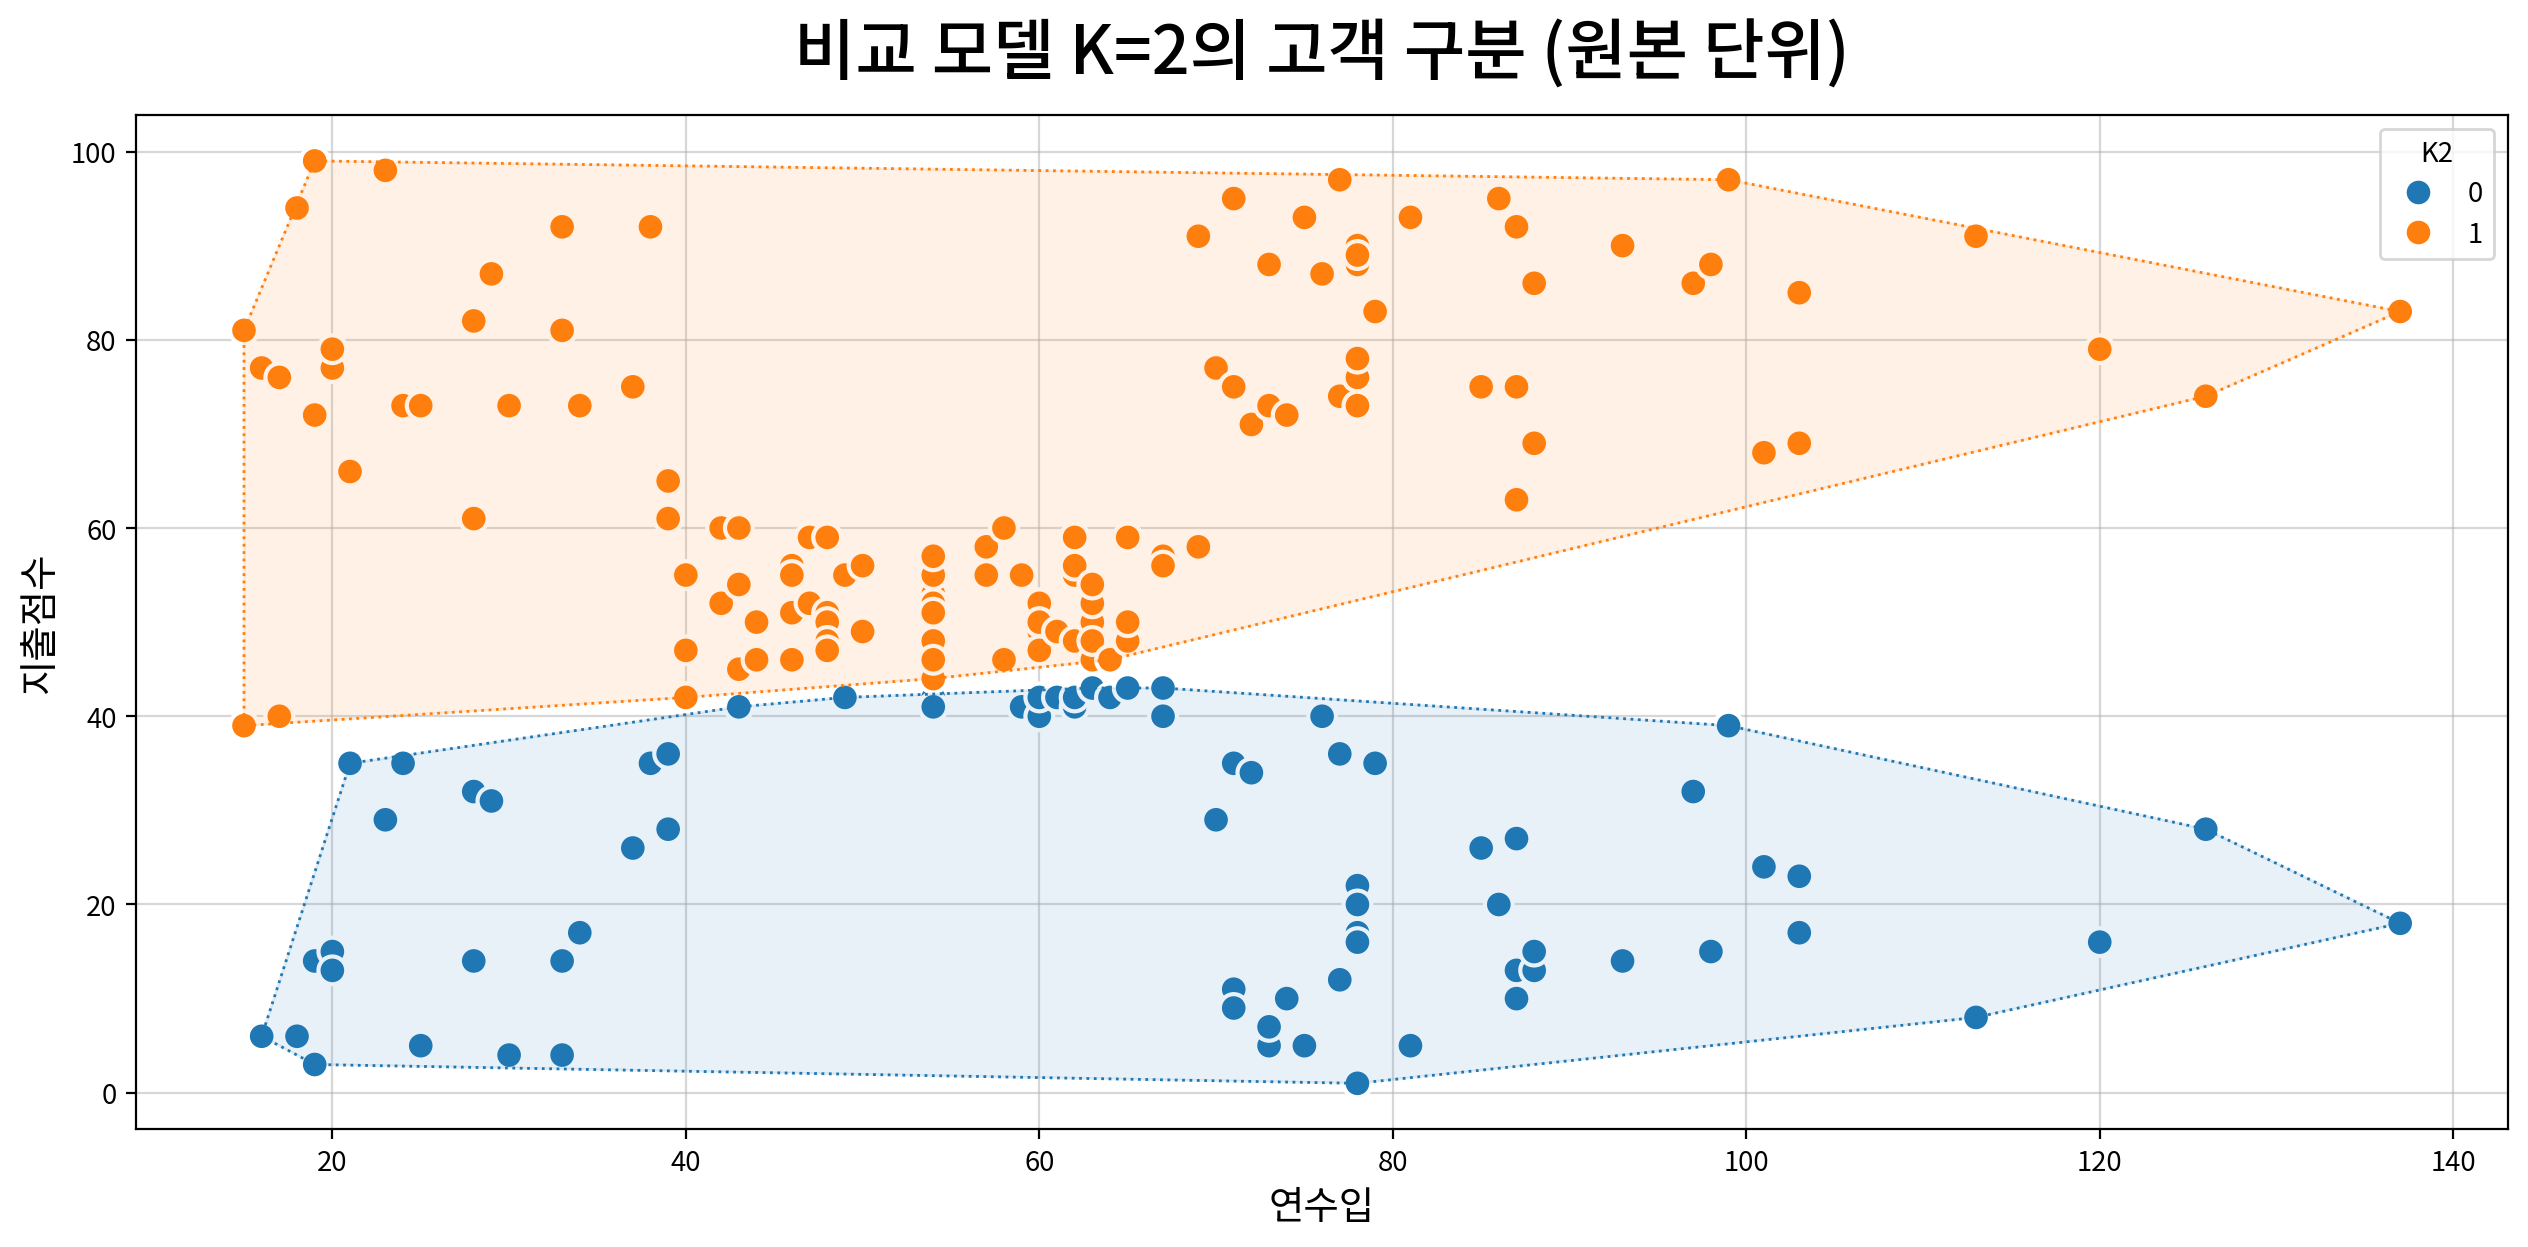

#### 두 후보의 평가 지표

,k,이너셔,감소량,스코어,전체면적,두께비,최소상대면적,균형지수
0,2,270.704,NaN,0.315,62.940,1.703,0.628,0.116
1,5,65.568,43.353,0.555,110.931,3.682,0.529,0.080


#### k=2 군집의 대표 특성 — 모두 평균값

,인원,평균연수입,평균지출점수
K2,,,
0,74,64.446,23.446
1,126,58.278,65.913


#### k=2 → k=5 고객 배정 교차표: 인원 / 행 기준 비율(%)

K5,0,1,2,3,4
K2,,,,,
0,18,21,35,0,0
1,63,2,0,22,39


K5,0,1,2,3,4
K2,,,,,
0,24.300,28.400,47.300,0.000,0.000
1,50.000,1.600,0.000,17.500,31.000


#### 실행 결과 해석: 같은 고객이 어떻게 나뉘었는가?

- k=2 군집 **0**의 **74명** → k=5 군집 0: 18명, k=5 군집 1: 21명, k=5 군집 2: 35명

- k=2 군집 **1**의 **126명** → k=5 군집 0: 63명, k=5 군집 1: 2명, k=5 군집 3: 22명, k=5 군집 4: 39명

In [47]:
estimator_k2, cdf_k2, center_k2 = my_cluster.kmeans(
    df, k=2, cluster_name="ClusterID", verbose=False, plot=False
)
comparison_df = origin[["고객ID", "연수입", "지출점수"]].copy()
comparison_df["K2"] = estimator_k2.labels_
comparison_df["K5"] = estimator.labels_

my_plot.scatterplot(
    data=comparison_df, x="연수입", y="지출점수", hue="K2",
    palette="tab10", title="비교 모델 K=2의 고객 구분 (원본 단위)"
)
display(Markdown("#### 두 후보의 평가 지표"))
display(result_df.loc[result_df["k"].isin([2, 5])].reset_index(drop=True))

display(Markdown("#### k=2 군집의 대표 특성 — 모두 평균값"))
display(comparison_df.groupby("K2").agg(
    인원=("고객ID", "size"), 평균연수입=("연수입", "mean"), 평균지출점수=("지출점수", "mean")
).round(3))

assignment_counts = crosstab(comparison_df["K2"], comparison_df["K5"])
assignment_ratio = assignment_counts.div(assignment_counts.sum(axis=1), axis=0) * 100
display(Markdown("#### k=2 → k=5 고객 배정 교차표: 인원 / 행 기준 비율(%)"))
display(assignment_counts)
display(assignment_ratio.round(1))

display(Markdown("#### 실행 결과 해석: 같은 고객이 어떻게 나뉘었는가?"))
for group, counts in assignment_counts.iterrows():
    parts = [f"k=5 군집 {label}: {int(count)}명" for label, count in counts.items() if count > 0]
    display(Markdown(f"- k=2 군집 **{group}**의 **{int(counts.sum())}명** → " + ", ".join(parts)))

#### 비교 결과를 해석하는 기준

k=5는 고객을 소득·지출점수의 다섯 가지 조합으로 구분할 수 있다는 장점이 있다. 위 교차표를 통해 k=2에서 함께 배정된 고객 중 어떤 고객들이 k=5에서는 서로 다른 군집에 배정되는지 확인할 수 있다. 산점도, 지표, 교차표를 함께 읽어 추가 세분화의 의미를 판단한다.

이 분석은 엘보우 포인트와 비교 후보 중 가장 높은 일반 실루엣 점수, 세분화 목적을 근거로 k=5를 유지한다. 다만 전체 평균 하나로 모든 고객의 배정이 명확하다고 주장하지 않으며, 군집별 진단에서 확인한 경계 사례는 해석의 한계로 함께 남긴다. 고객을 크게 두 부류로 관리하려는 목적이나 군집 크기 균형을 우선하는 목적이라면 k=2도 검토할 수 있다.

여기까지는 **군집 수와 분리 상태를 비교한 것**이다. 캠페인 성과, 초기값·표본 변화에 대한 안정성, 다른 알고리즘과의 비교는 수행하지 않았다.

## #03. 페르소나 도출

### 1. 원본 데이터에 군집 번호 붙이기

학습은 표준화된 데이터로 수행했고, 페르소나는 실제 수치를 읽기 쉬운 원본 단위로 해석한다. 군집화에 쓰지 않은 나이와 성별도 추가 설명 변수로 함께 살펴본다.


In [48]:
pdf = origin.copy()
pdf["ClusterID"] = estimator.labels_
pdf.head()

,고객ID,성별,나이,연수입,지출점수,ClusterID
0,1,Male,19,15,39,1
1,2,Male,21,15,81,3
2,3,Female,20,16,6,1
3,4,Female,23,16,77,3
4,5,Female,31,17,40,1


### 2. 군집에 사용된 변수와 그 밖의 변수 구분

In [49]:
# 군집을 만든 변수 (거리 계산에 사용)
cluster_columns = list(df.columns)

# 군집을 설명할 변수 (군집화에 쓰지 않은 나이·성별도 포함한다)
num_columns = ["나이"] + cluster_columns
cat_columns = my_qtcheck.get_categorical_column_names(origin)

print("군집화 변수:", cluster_columns)
print("해석 - 연속형:", num_columns)
print("해석 - 범주형:", cat_columns)

군집화 변수: ['연수입', '지출점수']
해석 - 연속형: ['나이', '연수입', '지출점수']
해석 - 범주형: ['성별']


### 3. 군집별 대표값 집계

군집별로 연속형 변수의 정규성을 검정하여, 유의수준 0.05에서 정규성을 기각하지 못하면 평균, 기각하면 중앙값을 대표값으로 사용한다. 범주형 변수는 최빈값을 사용한다.

**p>0.05가 정규분포임을 입증하는 것은 아니다.** 이 분석에서 대표값을 선택하는 기준이며, 출력되는 표에는 평균과 중앙값이 섞여 있다.

| 군집 | 나이 대표값 종류 | 연수입 대표값 종류 | 지출점수 대표값 종류 |
|---|---|---|---|
| 0 | 중앙값 | 중앙값 | 중앙값 |
| 1 | 평균 | 평균 | 중앙값 |
| 2 | 평균 | 중앙값 | 평균 |
| 3 | 평균 | 평균 | 평균 |
| 4 | 평균 | 중앙값 | 중앙값 |

아래 표를 모두 '평균값'이나 K-means의 '군집 중심점'으로 소개하지 않는다. 정규성 검정의 p값이 0.000으로 표시되면 표시 자릿수에 따른 반올림이며, 정확히 0이라는 뜻은 아니다.


In [50]:
persona_list = []           # 결과를 저장할 리스트

# --- 1) 군집수 만큼 반복 ---
for i in range(best_k):
    # 1-1) 현재 군집에 속한 데이터만 추출
    cluster_data = pdf[pdf["ClusterID"] == i]

    # 1-2) 군집별 요약 통계 생성
    persona_item = {"Cluster": i, "count": len(cluster_data)}

    # 1-3) 연속형 변수: 정규성 검정 결과에 따라 평균 또는 중앙값
    for column in num_columns:
        stat, p = normaltest(cluster_data[column])  # 정규성 검정

        if p > 0.05:    # 정규성을 기각하지 못하면 평균값
            persona_item[column] = round(cluster_data[column].mean(), 3)
            print(f"군집{i} - {column} : 정규성을 기각하지 못함 (p={p:.3f}) → 평균값 사용")
        else:           # 정규성을 기각하면 중앙값
            persona_item[column] = round(cluster_data[column].median(), 3)
            print(f"군집{i} - {column} : 정규성을 기각함 (p={p:.3f}) → 중앙값 사용")

    # 1-4) 범주형 변수: 최빈값
    for column in cat_columns:
        persona_item[column] = cluster_data[column].value_counts().idxmax()
        print(f"군집{i} - {column} : 최빈값 = {persona_item[column]}")

    # 1-5) 결과 리스트에 추가
    persona_list.append(persona_item)

# --- 2) 결과 확인 ---
# 데이터프레임으로 변환하고 군집 번호 기준으로 정렬
persona_df = DataFrame(persona_list).sort_values(by="Cluster")
persona_df

군집0 - 나이 : 정규성을 기각함 (p=0.000) → 중앙값 사용
군집0 - 연수입 : 정규성을 기각함 (p=0.013) → 중앙값 사용
군집0 - 지출점수 : 정규성을 기각함 (p=0.047) → 중앙값 사용
군집0 - 성별 : 최빈값 = Female
군집1 - 나이 : 정규성을 기각하지 못함 (p=0.846) → 평균값 사용
군집1 - 연수입 : 정규성을 기각하지 못함 (p=0.084) → 평균값 사용
군집1 - 지출점수 : 정규성을 기각함 (p=0.003) → 중앙값 사용
군집1 - 성별 : 최빈값 = Female
군집2 - 나이 : 정규성을 기각하지 못함 (p=0.602) → 평균값 사용
군집2 - 연수입 : 정규성을 기각함 (p=0.002) → 중앙값 사용
군집2 - 지출점수 : 정규성을 기각하지 못함 (p=0.441) → 평균값 사용
군집2 - 성별 : 최빈값 = Male
군집3 - 나이 : 정규성을 기각하지 못함 (p=0.228) → 평균값 사용
군집3 - 연수입 : 정규성을 기각하지 못함 (p=0.160) → 평균값 사용
군집3 - 지출점수 : 정규성을 기각하지 못함 (p=0.638) → 평균값 사용
군집3 - 성별 : 최빈값 = Female
군집4 - 나이 : 정규성을 기각하지 못함 (p=0.132) → 평균값 사용
군집4 - 연수입 : 정규성을 기각함 (p=0.001) → 중앙값 사용
군집4 - 지출점수 : 정규성을 기각함 (p=0.016) → 중앙값 사용
군집4 - 성별 : 최빈값 = Female


,Cluster,count,나이,연수입,지출점수,성별
0,0,81,46.000,54.000,50.000,Female
1,1,23,45.217,26.304,17.000,Female
2,2,35,41.114,85.000,17.114,Male
3,3,22,25.273,25.727,79.364,Female
4,4,39,32.692,79.000,83.000,Female


### 4. 군집별 나이 분포 확인

- **`나이` 는 군집화에 쓰지 않았다.**
- 그런데도 군집마다 분포가 다르다면, 그것은 "나이로 나눈 결과"가 아니라 **"나눠 놓고 보니 나이가 달랐다"** 는 뜻이다.

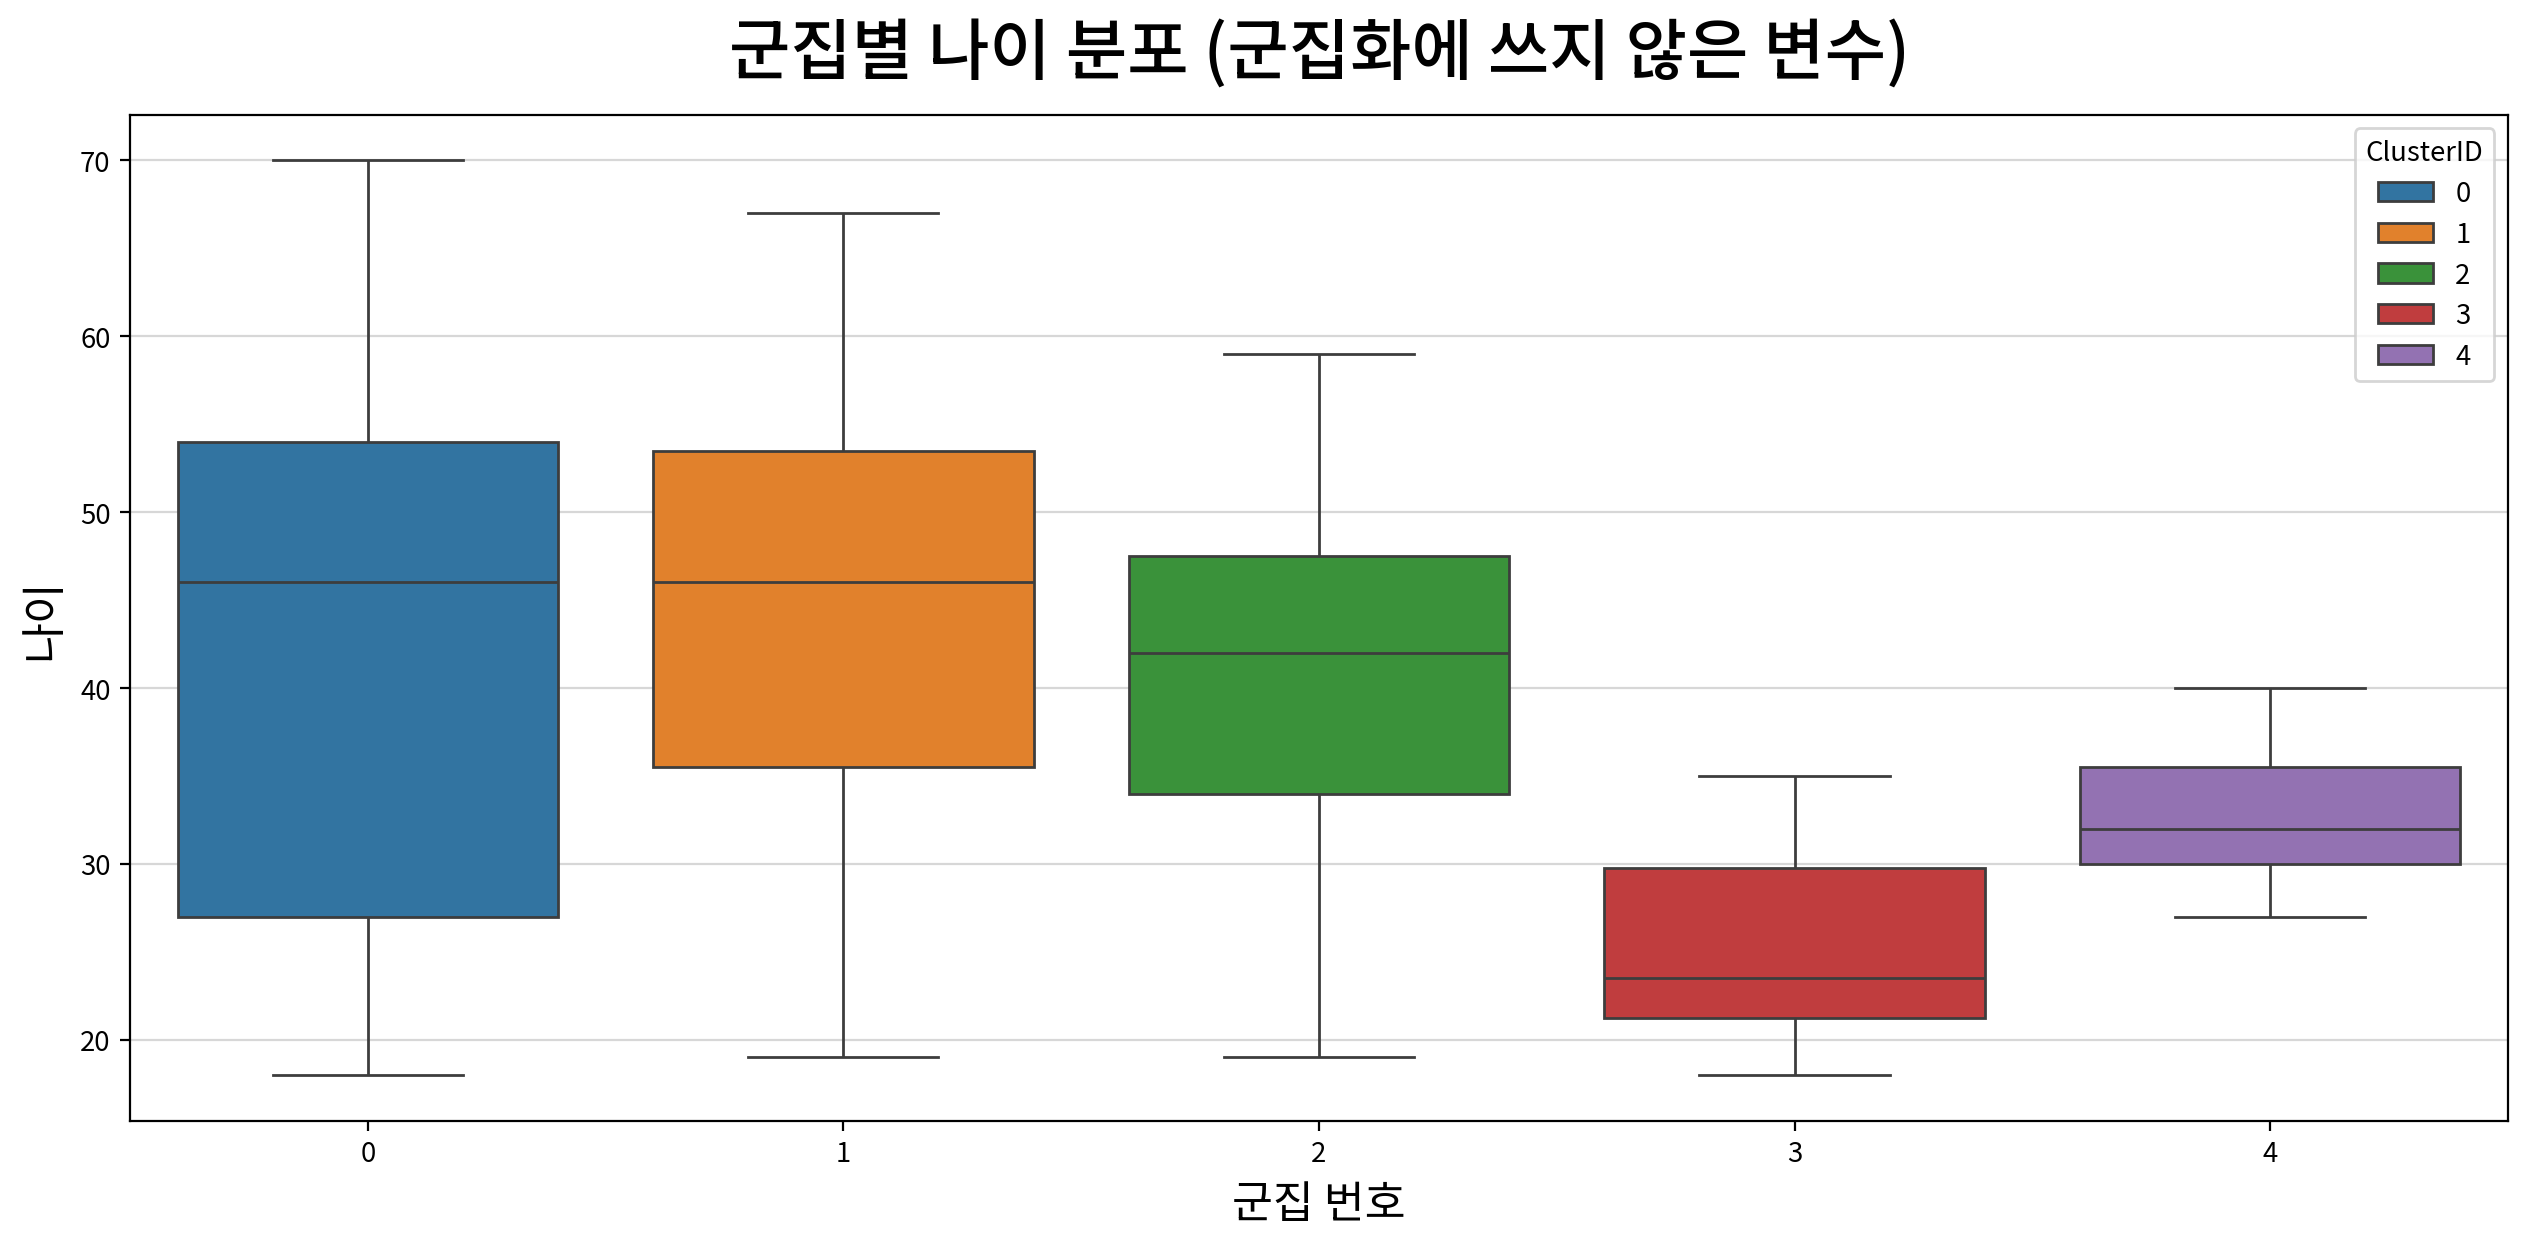

In [51]:
my_plot.boxplot(data=pdf, x="ClusterID", y="나이", hue="ClusterID", 
                title="군집별 나이 분포 (군집화에 쓰지 않은 변수)",
                xlabel="군집 번호", ylabel="나이", palette="tab10")

#### 나이 분포 해석

- 낮은 소득·높은 지출점수인 군집 3의 평균 나이는 약 **25.273세**, 높은 소득·높은 지출점수인 군집 4는 약 **32.692세**이다.
- 군집 0의 나이 중앙값은 **46세**이며, 군집 1·2의 평균 나이는 각각 약 **45.217세·41.114세**이다.
- 상자그림에서도 군집 3·4가 다른 군집보다 젊은 쪽에 분포한다. 상자 안의 가로선은 중앙값이므로 평균을 사용한 페르소나 대표값과 일치할 필요는 없다.

나이는 군집화에 사용하지 않았다. 이는 고객군을 나눈 뒤 관찰한 표본의 특성이며, '젊기 때문에 더 소비한다'는 인과관계나 전체 고객에 대한 일반화를 검증한 결과는 아니다.


### 5. 범주형 변수 비율 확인

- `성별` 의 최빈값은 대부분의 군집에서 같은 값이 나온다. 
- 이럴 때는 **구성비를 함께** 봐야 차이가 보인다.

In [52]:
# 군집 × 성별 교차표
ct = crosstab(pdf["ClusterID"], pdf["성별"])
display(ct)

# 비율로 환산 (행 기준 %)
display((ct.div(ct.sum(axis=1), axis=0) * 100).round(1))

성별,Female,Male
ClusterID,,
0,48,33
1,14,9
2,16,19
3,13,9
4,21,18


성별,Female,Male
ClusterID,,
0,59.300,40.700
1,60.900,39.100
2,45.700,54.300
3,59.100,40.900
4,53.800,46.200


#### 성별 구성비 해석

전체 여성은 112명(56.0%), 남성은 88명(44.0%)이다. 군집 0·1·3·4에서는 여성이 과반이며, **군집 2만 남성 19명(54.3%)으로 과반**이다.

따라서 최빈값뿐 아니라 구성비를 확인하면 높은 소득·낮은 지출점수 군집의 특성을 더 구체적으로 설명할 수 있다. 다만 군집 2의 여성도 16명(45.7%)이므로 '남성 고객군'으로 단정하지 않는다. 성별 차이에 대한 통계적 유의성이나 인과관계를 검증한 것은 아니다.


## #04. 페르소나 분석 활용

### 1. 새 고객 사례는 어느 그룹일까?

연수입과 지출점수를 알고 있는 가상의 고객 3명을 기존 군집에 배정한다. 신규 가입 시 지출점수를 아직 알 수 없다면 이 방식으로 바로 배정할 수는 없다.

> 새 데이터도 반드시 학습 때와 같은 기준으로 스케일링해야 한다. 이를 위해 앞에서 저장한 스케일러를 불러온다.


In [53]:
# 신규 고객 3명 (연수입, 지출점수)
new_data = [[70, 85],    # 소득도 높고 많이 쓴다
            [30, 20],    # 소득도 적고 적게 쓴다
            [88, 18]]    # 소득은 높은데 적게 쓴다

new_df = DataFrame(new_data, columns=df.columns)
new_df

,연수입,지출점수
0,70,85
1,30,20
2,88,18


### 2. 초기 분석과 동일한 스케일러 적용

In [54]:
# 저장해 둔 스케일러를 불러와 똑같은 기준으로 변환
scaler = joblib.load("models/mall_scaler.pkl")
new_scaled = DataFrame(scaler.transform(new_df), columns=df.columns)

display(new_scaled)

# 어느 군집에 속하는지 예측
print("예측된 군집:", estimator.predict(new_scaled))

,연수입,지출점수
0,0.360,1.351
1,-1.166,-1.172
2,1.047,-1.250


예측된 군집: [4 1 2]


#### 새 고객 배정 결과

가상의 고객 3명은 각각 **군집 4, 1, 2**로 배정되었다.

| 연수입 | 지출점수 | 배정 군집 | 해당 군집의 특성 |
|---:|---:|---:|---|
| 70 | 85 | 4 | 높은 소득·높은 지출점수 |
| 30 | 20 | 1 | 낮은 소득·낮은 지출점수 |
| 88 | 18 | 2 | 높은 소득·낮은 지출점수 |

입력 특성과 기존 페르소나가 일치하는 그룹으로 배정되었다. 이는 작동 예시이지 실제 신규 고객에서 성능을 검증한 결과는 아니다.

### 3. 고객군별 활용 가설과 필요한 데이터

다음 내용은 현재 자료로 확인한 사실과 **앞으로 검증할 계획**을 구분한 것이다. 아직 설문·캠페인·실험을 수행하지 않았으며, 반응률이나 매출 개선 수치를 결과로 제시하지 않는다.

| 대상 | 현재 관찰된 사실 | 아직 확인하지 않은 가설 | 추가로 필요한 정보 | 먼저 할 일 |
|---|---|---|---|---|
| 군집 2: 높은 소득·낮은 지출점수 35명(17.5%) | 소득에 비해 지출점수가 낮은 조합이다 | 방문 기회 부족, 상품 선호 불일치 등 서로 다른 이유가 있을 수 있다 | 방문·구매 이력, 선호 상품, 미구매 이유에 대한 설문 | 인터뷰·설문으로 원인을 먼저 탐색한다. 소득만 보고 할인 대상을 정하지 않는다 |
| 군집 4: 높은 소득·높은 지출점수 39명(19.5%) | 소득과 지출점수가 모두 높은 편이다 | 우대 프로그램 안내에 반응할 수 있다. 단, 이미 자주 구매하는지·수익성이 높은지는 모른다 | 재구매 이력, 기존 혜택, 상품별 마진·혜택 비용 | 실제 구매 및 수익성 정보를 확인한 뒤 우대 프로그램 후보로 검토한다 |

### 4. 활용 가설의 검증 계획 — 미실행 제안

1. **원인 확인:** 군집 2의 낮은 지출점수를 '구매력 부족'이나 '관심 없음'으로 해석하지 않는다. 응답자의 이유와 방문·구매 이력을 대조하여 어떤 제안이 적절할지 정한다. 설문 응답자가 전체 고객을 대표하지 않을 수 있다는 점도 기록한다.
2. **비교 가능한 실험:** 실제 고객 데이터와 충분한 대상자가 확보되면 해당 고객군 안에서 무작위로 제안군과 비교군을 배정한다. 군집 2와 군집 4의 성과를 단순 비교해 캠페인 효과라고 주장하지 않는다. 두 군집은 원래 특성이 다르기 때문이다.
3. **측정 기준 사전 정의:** 제안 내용과 관찰 기간을 먼저 정하고, 구매 전환율을 '기간 내 구매한 고객 수 ÷ 배정된 전체 고객 수'로 계산한다. 가능하면 고객당 매출뿐 아니라 할인·혜택·접촉 비용을 반영한 고객당 이익 차이도 확인한다. 수신 거부·불만 증가도 함께 점검한다.
4. **판단:** 클릭이나 설문 응답만 늘었다고 구매·이익 개선으로 간주하지 않는다. 두 집단의 차이와 불확실성을 확인한 후 확대 여부를 결정한다. 효과가 없거나 비용이 더 크면 제안을 수정하거나 중단한다.
5. **표본의 한계:** 현재 군집별 인원 35명·39명만으로는 작은 효과를 구분하기 어려울 수 있다. 필요 표본 수와 관찰 기간은 실제 기준 전환율, 검출하려는 효과 크기 등을 바탕으로 별도 설계해야 한다. 이 데이터만으로 실험 가능성을 확정하지 않는다.

군집 0·1·3도 고객 특성을 설명하는 결과에 포함된다. 위 두 군집은 활용 계획을 구체화하기 위해 선택한 예시이지, 수익성 순위나 고객 배제 기준이 아니다. 경계 사례는 단일 군집명만으로 단정적인 조치를 취하지 않고 추가 정보를 함께 확인한다.

### 결론과 한계

고객을 소득만으로 구분하지 않고 지출점수를 함께 사용하여 중간층과 소득·지출점수가 서로 다른 네 고객군을 구분했다. 나이·성별은 군집을 만드는 변수가 아니라 고객군을 설명하는 보조 정보로 활용했다. 추가 진단에서는 최종 군집별 분리 상태와 k=2·k=5의 고객 배정 차이를 표와 그래프로 확인한다.

- k=5는 분리 정도와 해석 목적을 고려한 선택이다. 크기 균형을 중시하는 지표는 k=2를 추천했다.
- 표본은 200명이고 군집화에는 두 변수만 사용했다. 다른 고객 집단이나 시점에서도 같은 구조가 유지되는지, 초기값에 민감한지는 검증하지 않았다.
- 지출점수는 실제 구매금액·구매빈도·수익성 자체가 아니다. 이 자료만으로 고객가치나 캠페인 효과를 측정했다고 주장하지 않는다.
- 활용 계획은 의사결정을 위한 다음 단계의 제안이다. 실제 실행과 효과 검증에는 추가 데이터가 필요하다.
